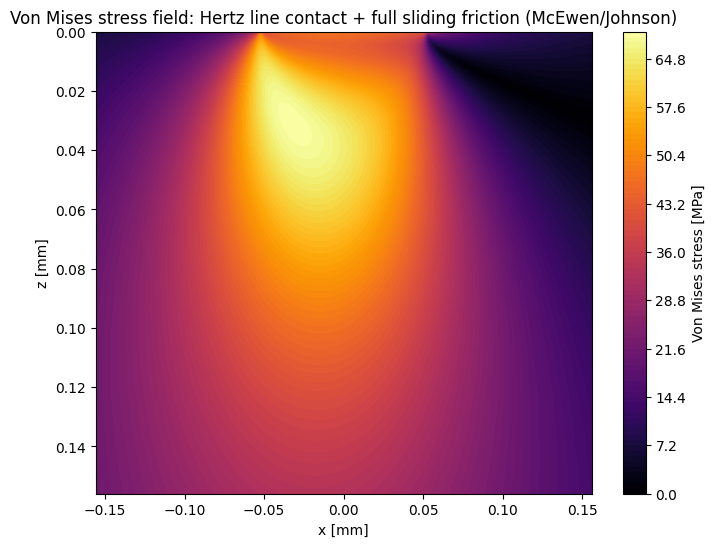

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# McEwen / Johnson: sliding (full slip) line contact on a half-space
# Normal Hertz pressure p(x)=p0*sqrt(1-(x/a)^2)
# Tangential traction q(x)=q0*sqrt(1-(x/a)^2), with q0 = ± mu * p0
#
# Total stresses = ( ... )_p  +  ( ... )_q   (linear superposition)
#
# References (Johnson):
# - McEwen m,n definition and normal field (Eq. 4.48–4.49) :contentReference[oaicite:3]{index=3}
# - Sliding traction and stress identities + (σx)_q (Eq. 7.4–7.6) :contentReference[oaicite:4]{index=4}
# ============================================================

# -----------------------
# 1) Inputs (SI units)
# -----------------------
# Body 1: Cylinder (e.g., steel-like values here)
E1 = 210e9         # Young's modulus [Pa]
nu1 = 0.30         # Poisson ratio [-]
R = 1e-3           # Cylinder radius [m]

# Body 2: Flat (e.g., PEEK 450G-like values)
E2 = 4.0e9         # Young's modulus [Pa]
nu2 = 0.41         # Poisson ratio [-]
sigma_yc_2 = 125e6 # Compressive yield/strength proxy [Pa] (datasheet dependent!)

# Geometry / load
L = 10e-3          # Effective contact length (axial) [m]
F = 100.0          # Total normal load over the length L [N]
mu = 0.2     # coefficient of friction

# -----------------------
# 2) Reduced (composite) modulus E' (a.k.a. E*)
#    1/E' = (1-nu1^2)/E1 + (1-nu2^2)/E2
# -----------------------
Eprime = 1.0 / ((1.0 - nu1**2)/E1 + (1.0 - nu2**2)/E2)  # [Pa]

# -----------------------
# 3) Hertz line-contact results
# -----------------------
# Contact half-width b [m]
a = np.sqrt((4.0 * F * R) / (np.pi * L * Eprime))

# Peak pressure p0 (your Pmax) [Pa]
p0 = 2.0 * F / (np.pi * a * L)



# Direction convention:
# Johnson notes a sign convention linked to sliding velocity (Fig. 7.1).
# For Von Mises magnitudes, the sign mostly affects tension/compression location,
# not the magnitude. Choose sgn = -1 or +1 to match your sliding direction.
sgn = -1.0
q0 = sgn * mu * p0   # peak tangential traction at x=0 [Pa]

# -----------------------
# McEwen auxiliary funcs
# -----------------------
def m_fun(a, x, z):
    # m >= 0 for z >= 0 (half-space), so sign is simply + for our domain
    A = a*a - x*x + z*z
    B = np.sqrt(A*A + 4.0*x*x*z*z)
    return np.sqrt(0.5*(B + A))

def n_fun(a, x, z):
    # IMPORTANT: McEwen definition requires sign(n) = sign(x)
    A = a*a - x*x + z*z
    B = np.sqrt(A*A + 4.0*x*x*z*z)
    n_abs = np.sqrt(0.5*(B - A))
    return np.sign(x) * n_abs

def _den(mv, nv, eps=1e-30):
    return np.maximum(mv*mv + nv*nv, eps)

# -----------------------
# Normal (pressure) field: ( ... )_p  (Eq. 4.49) :contentReference[oaicite:5]{index=5}
# -----------------------
def sigma_x_p(p0, a, x, z):
    mv = m_fun(a, x, z)
    nv = n_fun(a, x, z)
    den = _den(mv, nv)
    return -(p0/a) * (mv * (1.0 + (z*z + nv*nv)/den) - 2.0*z)

def sigma_z_p(p0, a, x, z):
    mv = m_fun(a, x, z)
    nv = n_fun(a, x, z)
    den = _den(mv, nv)
    return -(p0/a) * mv * (1.0 - (z*z + nv*nv)/den)

def tau_xz_p(p0, a, x, z):
    mv = m_fun(a, x, z)
    nv = n_fun(a, x, z)
    den = _den(mv, nv)
    return -(p0/a) * nv * ((mv*mv - z*z)/den)

# -----------------------
# Tangential (friction) field: ( ... )_q
# Using Johnson identities (Eq. 7.5) and explicit σx_q (Eq. 7.6)
# :contentReference[oaicite:6]{index=6}
# -----------------------
def sigma_z_q(q0, p0, a, x, z):
    # (σz)_q / q0 = (τxz)_p / p0
    return (q0/p0) * tau_xz_p(p0, a, x, z)

def tau_xz_q(q0, p0, a, x, z):
    # (τxz)_q / q0 = (σx)_p / p0
    return (q0/p0) * sigma_x_p(p0, a, x, z)

def sigma_x_q(q0, a, x, z):
    # Eq. (7.6): (σx)_q = (q0/a){ n( 2 - (z^2 - m^2)/(m^2 + n^2) ) - 2x }
    mv = m_fun(a, x, z)
    nv = n_fun(a, x, z)
    den = _den(mv, nv)
    return (q0/a) * (nv * (2.0 - (z*z - mv*mv)/den) - 2.0*x)

# -----------------------
# Combine + plane strain σy and Von Mises
# -----------------------
def sigma_components_total(p0, q0, a, x, z, nu2):
    sx = sigma_x_p(p0, a, x, z) + sigma_x_q(q0, a, x, z)
    sz = sigma_z_p(p0, a, x, z) + sigma_z_q(q0, p0, a, x, z)
    txz = tau_xz_p(p0, a, x, z) + tau_xz_q(q0, p0, a, x, z)

    # plane strain in out-of-plane direction (same convention you used earlier)
    sy = nu2 * (sx + sz)
    return sx, sy, sz, txz

def von_mises_from_components(sx, sy, sz, txz):
    return np.sqrt(0.5*((sx - sy)**2 + (sy - sz)**2 + (sz - sx)**2) + 3.0*txz**2)

def sigma_von_mises_mcewen(p0, q0, a, x, z, nu2):
    sx, sy, sz, txz = sigma_components_total(p0, q0, a, x, z, nu2)
    return von_mises_from_components(sx, sy, sz, txz)

# -----------------------
# Plot VM field
# -----------------------
x_vals = np.linspace(-3*a, 3*a, 400)
z_vals = np.linspace(0.0, 3*a, 300)

X, Z = np.meshgrid(x_vals, z_vals)

VM = sigma_von_mises_mcewen(p0, q0, a, X, Z, nu2) / 1e6  # MPa

plt.figure(figsize=(8,6))
cs = plt.contourf(X*1e3, Z*1e3, VM, levels=100, cmap="inferno")
plt.colorbar(cs, label="Von Mises stress [MPa]")
plt.xlabel("x [mm]")
plt.ylabel("z [mm]")
plt.title("Von Mises stress field: Hertz line contact + full sliding friction (McEwen/Johnson)")
plt.gca().invert_yaxis()
plt.show()